# AI Infrastructure Market Pulse

This notebook asks how a defined AI-infrastructure market-price basket moved over the selected window. The basket is a public price proxy for attention around compute, cloud, chips, platforms, and adjacent high-interest names.

The output is a basket definition, a source card, trend-index figures, return-versus-trend comparison, and edge-trimmed residual events. Revenue, capex, margins, and valuation require official financial data.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.hot_trends.data import (
    HotTrendDataError,
    append_real_snapshot,
    build_arxiv_monthly_counts,
    fetch_coingecko_market_chart,
    fetch_defillama_stablecoin_chains,
    fetch_github_repo_metadata,
    fetch_github_stargazers,
    fetch_huggingface_models,
    fetch_wikipedia_pageviews,
    source_audit_table,
)
from examples.hot_trends.decomposition import (
    component_summary,
    decompose_table,
    editorial_priority,
    residual_event_table,
)
from examples.hot_trends.scoring import article_publication_phrasing

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"axes.grid": True})

CACHE_DIR = Path("examples/hot_trends/cache")
OUTPUT_DIR = Path("examples/hot_trends/outputs")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"saved: {path.as_posix()}")


## 1. Fetch prices through yfinance


In [2]:
try:
    import yfinance as yf
except Exception as exc:
    raise ImportError("Install yfinance to run this notebook: python -m pip install yfinance") from exc

basket_definition = pd.DataFrame([
    {"ticker": "NVDA", "role": "GPU accelerator supplier", "boundary": "large-cap chip proxy, not pure infrastructure revenue"},
    {"ticker": "AMD", "role": "GPU/CPU accelerator challenger", "boundary": "mixed client, data-center, and gaming exposure"},
    {"ticker": "AVGO", "role": "networking and custom silicon", "boundary": "diversified semiconductor and software exposure"},
    {"ticker": "MSFT", "role": "cloud and AI platform", "boundary": "large diversified software/cloud company"},
    {"ticker": "GOOGL", "role": "cloud, TPU, and AI platform", "boundary": "advertising remains a major business line"},
    {"ticker": "AMZN", "role": "cloud infrastructure", "boundary": "retail and marketplace exposure included"},
    {"ticker": "META", "role": "AI compute demand and model deployment", "boundary": "advertising platform, not infrastructure vendor"},
    {"ticker": "TSLA", "role": "AI narrative and autonomous systems proxy", "boundary": "auto and energy exposure dominates fundamentals"},
])
tickers = basket_definition["ticker"].tolist()
start_date = "2024-01-01"
raw = yf.download(tickers, start=start_date, progress=False, auto_adjust=True)["Close"]
if raw.empty:
    raise HotTrendDataError("yfinance returned no market data")
prices = raw.reset_index().melt(id_vars="Date", var_name="ticker", value_name="price").rename(columns={"Date": "date"})
prices = prices.dropna(subset=["price"])
display(basket_definition)
prices.head(20)


,ticker,role,boundary
0,NVDA,GPU accelerator supplier,"large-cap chip proxy, not pure infrastructure ..."
1,AMD,GPU/CPU accelerator challenger,"mixed client, data-center, and gaming exposure"
2,AVGO,networking and custom silicon,diversified semiconductor and software exposure
3,MSFT,cloud and AI platform,large diversified software/cloud company
4,GOOGL,"cloud, TPU, and AI platform",advertising remains a major business line
5,AMZN,cloud infrastructure,retail and marketplace exposure included
6,META,AI compute demand and model deployment,"advertising platform, not infrastructure vendor"
7,TSLA,AI narrative and autonomous systems proxy,auto and energy exposure dominates fundamentals


,date,ticker,price
0,2024-01-02,AMD,138.580002
1,2024-01-03,AMD,135.320007
2,2024-01-04,AMD,136.009995
3,2024-01-05,AMD,138.580002
4,2024-01-08,AMD,146.179993
5,2024-01-09,AMD,149.259995
6,2024-01-10,AMD,148.539993
7,2024-01-11,AMD,148.020004
8,2024-01-12,AMD,146.559998
9,2024-01-16,AMD,158.740005


## 2. Source card and price audit


In [3]:
audit = source_audit_table(prices, value_col="price", entity_col="ticker", time_col="date")
source_card = pd.DataFrame([{
    "source": "Yahoo Finance through yfinance",
    "endpoint": "yfinance.download",
    "access_date": pd.Timestamp.today().date().isoformat(),
    "query_params": f"tickers={','.join(tickers)}; start={start_date}; auto_adjust=True; field=Close",
    "time_range": f"{pd.to_datetime(prices['date']).min().date()} to {pd.to_datetime(prices['date']).max().date()}",
    "cache_path": "not cached; outputs saved to examples/hot_trends/outputs",
    "interpretation_scope": "public market-price proxy for a defined basket; not fundamentals, valuation, or investment advice",
}])
display(source_card)
audit


,source,endpoint,access_date,query_params,time_range,cache_path,interpretation_scope
0,Yahoo Finance through yfinance,yfinance.download,2026-05-22,"tickers=NVDA,AMD,AVGO,MSFT,GOOGL,AMZN,META,TSL...",2024-01-02 to 2026-05-22,not cached; outputs saved to examples/hot_tren...,public market-price proxy for a defined basket...


,series,first_timestamp,last_timestamp,observations,missing_ratio,min_value,max_value
0,AMD,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,78.209999,467.510010
1,AMZN,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,144.570007,274.989990
2,AVGO,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,102.365158,439.790009
3,GOOGL,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,130.322876,402.619995
4,META,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,341.787811,788.148987
5,MSFT,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,351.105774,538.658508
6,NVDA,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,47.539936,235.740005
7,TSLA,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,142.050003,489.880005


## 3. Decompose normalized log prices


In [4]:
components = decompose_table(prices, entity_col="ticker", time_col="date", value_col="price", method="MA_BASELINE", period=21, trend_window=63, transform="log")
summary = editorial_priority(component_summary(components, entity_col="ticker", time_col="date"), entity_col="ticker")
summary


,ticker,observations,first_timestamp,last_timestamp,trend_last,trend_slope_per_step,cycle_strength_proxy,residual_std,max_abs_residual_z,method,trend_slope_per_step_rank_pct,cycle_strength_proxy_rank_pct,max_abs_residual_z_rank_pct,editorial_priority_score
2,AVGO,600,2024-01-02 00:00:00,2026-05-22 00:00:00,3.056002,0.002033,-0.515611,0.492248,31.542094,MA_BASELINE,1.000,1.000,0.500,0.77500
3,GOOGL,600,2024-01-02 00:00:00,2026-05-22 00:00:00,2.996327,0.001351,-1.894425,0.500717,38.908369,MA_BASELINE,0.625,0.500,1.000,0.76875
6,NVDA,600,2024-01-02 00:00:00,2026-05-22 00:00:00,2.710889,0.001477,-0.730896,0.425016,30.472988,MA_BASELINE,0.750,0.875,0.375,0.60625
7,TSLA,600,2024-01-02 00:00:00,2026-05-22 00:00:00,3.037916,0.001532,-1.559972,0.528218,30.440903,MA_BASELINE,0.875,0.750,0.250,0.56875
4,META,600,2024-01-02 00:00:00,2026-05-22 00:00:00,3.277547,0.000695,-8.994860,0.545159,34.034109,MA_BASELINE,0.500,0.375,0.625,0.53125
1,AMZN,600,2024-01-02 00:00:00,2026-05-22 00:00:00,2.824287,0.000536,-12.700004,0.479970,38.328541,MA_BASELINE,0.250,0.250,0.750,0.47500
5,MSFT,600,2024-01-02 00:00:00,2026-05-22 00:00:00,3.058471,0.000199,-28.797940,0.536863,38.792840,MA_BASELINE,0.125,0.125,0.875,0.46250
0,AMD,600,2024-01-02 00:00:00,2026-05-22 00:00:00,2.973933,0.000667,-1.836756,0.521744,29.756925,MA_BASELINE,0.375,0.625,0.125,0.31250


## Visualization: AI infrastructure price trend index

The y-axis is an index with each ticker starting at 1. Solid trend lines make basket movement comparable across different share prices. This is a price-proxy view; benchmark and financial-statement evidence are needed before performance or valuation claims.


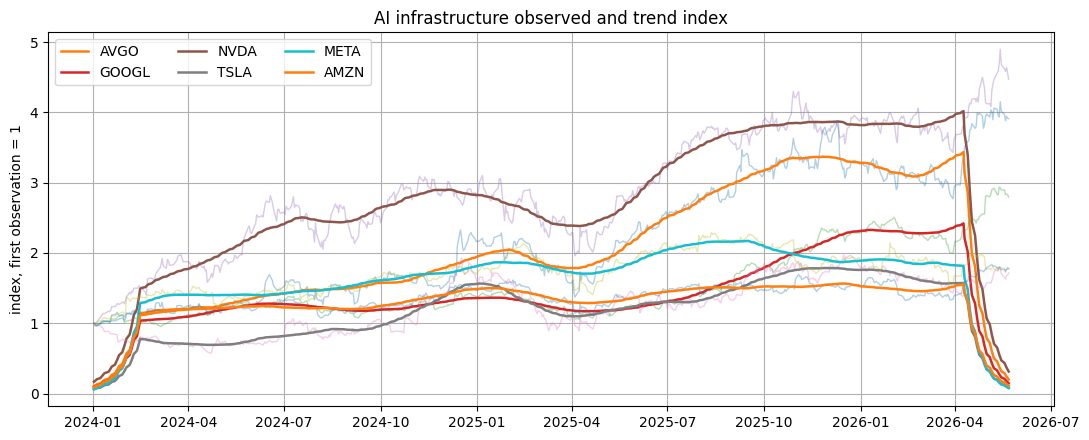

In [5]:
top_tickers = summary["ticker"].head(6).tolist()
fig, ax = plt.subplots(figsize=(11, 4.5))
for ticker in top_tickers:
    panel = components.loc[components["ticker"].eq(ticker)].sort_values("date").copy()
    panel["date"] = pd.to_datetime(panel["date"])
    base = float(panel["observed"].iloc[0])
    observed_index = np.exp(panel["observed"] - base)
    trend_index = np.exp(panel["trend"] - base)
    ax.plot(panel["date"], observed_index, linewidth=1.0, alpha=0.35)
    ax.plot(panel["date"], trend_index, linewidth=1.8, label=ticker)
ax.set_title("AI infrastructure observed and trend index")
ax.set_ylabel("index, first observation = 1")
ax.legend(ncol=3, loc="best")
plt.tight_layout()
plt.show()


## 4. Cross-sectional AI infrastructure table


In [6]:
latest = prices.sort_values("date").groupby("ticker").tail(1).rename(columns={"price": "latest_price"})
first = prices.sort_values("date").groupby("ticker").head(1).rename(columns={"price": "first_price"})[["ticker", "first_price"]]
returns = latest.merge(first, on="ticker", how="left")
returns["total_return_proxy"] = returns["latest_price"] / returns["first_price"] - 1.0
returns.sort_values("total_return_proxy", ascending=False)


,date,ticker,latest_price,first_price,total_return_proxy
6,2026-05-22,NVDA,215.330002,48.138569,3.473128
3,2026-05-22,AVGO,414.140015,105.914253,2.910144
5,2026-05-22,AMD,467.510010,138.580002,2.373575
0,2026-05-22,GOOGL,382.970001,137.037384,1.794639
4,2026-05-22,AMZN,266.320007,149.929993,0.776296
2,2026-05-22,META,610.260010,343.593658,0.776110
7,2026-05-22,TSLA,426.010010,248.419998,0.714878
1,2026-05-22,MSFT,418.570007,363.801514,0.150545


## Visualization: return versus trend slope

The x-axis is simple total return over the sampled window. The y-axis is De-Time trend slope; marker size reflects residual shock magnitude. Read the scatter as a basket diagnostic, not as a recommendation.


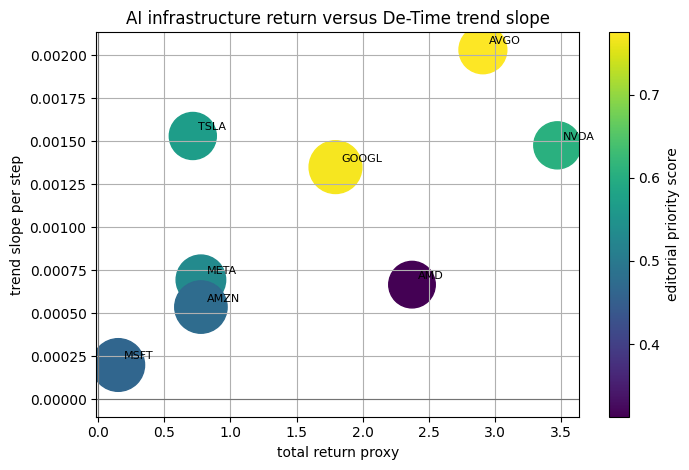

In [7]:
scatter_data = returns.merge(summary[["ticker", "trend_slope_per_step", "max_abs_residual_z", "editorial_priority_score"]], on="ticker", how="left")
fig, ax = plt.subplots(figsize=(7.2, 4.8))
sc = ax.scatter(
    scatter_data["total_return_proxy"],
    scatter_data["trend_slope_per_step"],
    s=80 + scatter_data["max_abs_residual_z"].fillna(0) * 35,
    c=scatter_data["editorial_priority_score"],
    cmap="viridis",
)
for _, row in scatter_data.iterrows():
    ax.annotate(str(row["ticker"]), (row["total_return_proxy"], row["trend_slope_per_step"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axvline(0, color="0.45", linewidth=0.8)
ax.axhline(0, color="0.45", linewidth=0.8)
ax.set_xlabel("total return proxy")
ax.set_ylabel("trend slope per step")
ax.set_title("AI infrastructure return versus De-Time trend slope")
fig.colorbar(sc, ax=ax, label="editorial priority score")
plt.tight_layout()
plt.show()


## 5. Residual events


In [8]:
events = residual_event_table(components, entity_col="ticker", time_col="date", top_n=25, trim_edges=63)
events


,date,ticker,observed,trend,season,residual,residual_z,abs_residual_z,method
0,2025-04-04,AVGO,4.977521,5.241958,0.014480,-0.278917,-3.450883,3.450883,MA_BASELINE
1,2025-03-10,TSLA,5.403353,5.674217,0.017037,-0.287901,-3.276988,3.276988,MA_BASELINE
2,2025-04-08,AMD,4.359398,4.608465,0.031801,-0.280868,-3.153715,3.153715,MA_BASELINE
3,2025-10-29,AMD,5.577198,5.362060,-0.050298,0.265437,3.070146,3.070146,MA_BASELINE
4,2025-10-27,AMD,5.559412,5.352499,-0.053735,0.260648,3.015589,3.015589,MA_BASELINE
5,2025-04-21,META,6.180333,6.374351,0.038095,-0.232114,-2.988468,2.988468,MA_BASELINE
6,2025-04-21,NVDA,4.573547,4.756973,0.037131,-0.220557,-2.987761,2.987761,MA_BASELINE
7,2025-03-18,TSLA,5.417477,5.640343,0.039234,-0.262100,-2.980770,2.980770,MA_BASELINE
8,2024-12-26,AVGO,5.491635,5.313243,-0.052179,0.230571,2.932011,2.932011,MA_BASELINE
9,2025-04-07,AVGO,5.029791,5.242214,0.021533,-0.233956,-2.887612,2.887612,MA_BASELINE


## Visualization: AI infrastructure residual heatmap

The heatmap shows weekly residual z-scores by ticker after decomposition. Clusters suggest dates worth matching against launches, earnings, or macro events; edge-trimmed residual tables reduce first/last-window artifacts.


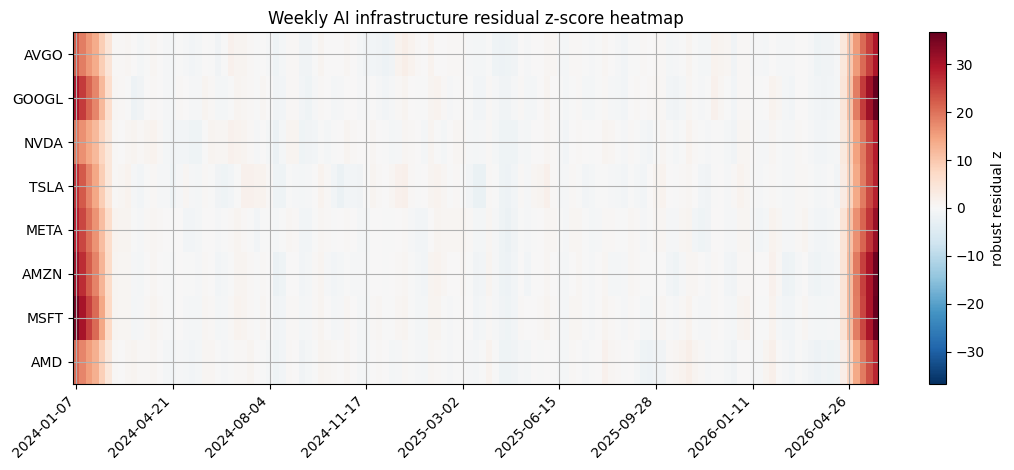

In [9]:
residual_grid = components.copy()
residual_grid["residual_z"] = residual_grid.groupby("ticker")["residual"].transform(lambda s: (s - s.median()) / (1.4826 * (s - s.median()).abs().median() + 1e-12))
heat = residual_grid.pivot_table(index="ticker", columns="date", values="residual_z", aggfunc="mean").reindex(summary["ticker"].tolist()).dropna(how="all")
heat = heat.T
heat.index = pd.to_datetime(heat.index)
heat = heat.resample("W").mean().T
values = heat.to_numpy(dtype=float)
absmax = float(np.nanmax(np.abs(values))) if np.isfinite(values).any() else 1.0
fig, ax = plt.subplots(figsize=(11, 4.8))
im = ax.imshow(values, aspect="auto", cmap="RdBu_r", vmin=-absmax, vmax=absmax)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
tick_step = max(1, len(heat.columns) // 8)
xticks = list(range(0, len(heat.columns), tick_step))
ax.set_xticks(xticks)
ax.set_xticklabels([heat.columns[i].strftime("%Y-%m-%d") for i in xticks], rotation=45, ha="right")
ax.set_title("Weekly AI infrastructure residual z-score heatmap")
fig.colorbar(im, ax=ax, label="robust residual z")
plt.tight_layout()
plt.show()


## 6. Publication language


In [10]:
phrasing = article_publication_phrasing()
phrasing


,draft_claim,evidence_based_phrasing
0,This trend predicts the next price move.,This trend summarizes the observed public seri...
1,This model is better because it has more downl...,Downloads are a public adoption proxy interpre...
2,This repo is winning because stars are rising.,Star velocity measures developer attention for...
3,This pageview spike shows the topic matters most.,Pageviews measure public attention during the ...
4,This residual is a buy signal.,This residual marks an event-like deviation fr...


In [11]:
save_table(source_card, "07_ai_infra_source_card")
save_table(basket_definition, "07_ai_infra_basket_definition")
save_table(audit, "07_ai_infra_market_audit")
save_table(summary, "07_ai_infra_component_summary")
save_table(returns, "07_ai_infra_return_proxy")
save_table(events, "07_ai_infra_residual_events")
save_table(phrasing, "07_ai_infra_publication_phrasing")


saved: examples/hot_trends/outputs/07_ai_infra_source_card.csv
saved: examples/hot_trends/outputs/07_ai_infra_basket_definition.csv
saved: examples/hot_trends/outputs/07_ai_infra_market_audit.csv
saved: examples/hot_trends/outputs/07_ai_infra_component_summary.csv
saved: examples/hot_trends/outputs/07_ai_infra_return_proxy.csv
saved: examples/hot_trends/outputs/07_ai_infra_residual_events.csv
saved: examples/hot_trends/outputs/07_ai_infra_publication_phrasing.csv
